In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/Unemployment in India.csv')

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
df_covid = pd.read_csv(
    '/content/Unemployment_Rate_upto_11_2020.csv'
)

df_covid.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [4]:
df.columns = df.columns.str.strip()
df_covid.columns = df_covid.columns.str.strip()

print("First dataset columns:")
print(df.columns.tolist())

print("\nSecond dataset columns:")
print(df_covid.columns.tolist())

First dataset columns:
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']

Second dataset columns:
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


In [5]:
print("First dataset shape:", df.shape)
print("Second dataset shape:", df_covid.shape)

First dataset shape: (768, 7)
Second dataset shape: (267, 9)


In [6]:
print(df.isnull().sum())

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


In [7]:
df = df.dropna(how='all')

print("Shape after removing empty rows:", df.shape)

Shape after removing empty rows: (740, 7)


In [8]:
print(df.isnull().sum())

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


In [9]:
df = df.dropna(
    subset=[
        'Region',
        'Date',
        'Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)'
    ]
)

In [10]:
print(df.isnull().sum())

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (740, 7)


In [13]:
df['Date'] = pd.to_datetime(
    df['Date'],
    dayfirst=True,
    errors='coerce'
)

df_covid['Date'] = pd.to_datetime(
    df_covid['Date'],
    dayfirst=True,
    errors='coerce'
)

In [14]:
print(df['Date'].min())
print(df['Date'].max())

2019-05-31 00:00:00
2020-06-30 00:00:00


In [15]:
df['Region'] = df['Region'].str.strip()
df['Frequency'] = df['Frequency'].str.strip()
df['Area'] = df['Area'].str.strip()

df_covid['Region'] = df_covid['Region'].str.strip()
df_covid['Frequency'] = df_covid['Frequency'].str.strip()

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


In [17]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [18]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [19]:
print("Number of regions:", df['Region'].nunique())

print("\nRegions:")
print(df['Region'].unique())

Number of regions: 28

Regions:
['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' 'Chandigarh']


In [20]:
print(df['Area'].value_counts())

Area
Urban    381
Rural    359
Name: count, dtype: int64


In [21]:
average_unemployment = df[
    'Estimated Unemployment Rate (%)'
].mean()

print(
    "Average Unemployment Rate:",
    round(average_unemployment, 2),
    "%"
)

Average Unemployment Rate: 11.79 %


In [22]:
highest = df.loc[
    df['Estimated Unemployment Rate (%)'].idxmax()
]

print("Highest unemployment record:")
print(highest)

Highest unemployment record:
Region                                              Puducherry
Date                                       2020-04-30 00:00:00
Frequency                                              Monthly
Estimated Unemployment Rate (%)                          76.74
Estimated Employed                                     68122.0
Estimated Labour Participation Rate (%)                  35.54
Area                                                     Urban
Name: 627, dtype: object


In [23]:
lowest = df.loc[
    df['Estimated Unemployment Rate (%)'].idxmin()
]

print("Lowest unemployment record:")
print(lowest)

Lowest unemployment record:
Region                                                   Assam
Date                                       2020-06-30 00:00:00
Frequency                                              Monthly
Estimated Unemployment Rate (%)                            0.0
Estimated Employed                                   7544937.0
Estimated Labour Participation Rate (%)                  34.38
Area                                                     Rural
Name: 25, dtype: object


## Unemployment Rate Trend Over Time

This section examines how the unemployment rate changed over the
observed period.

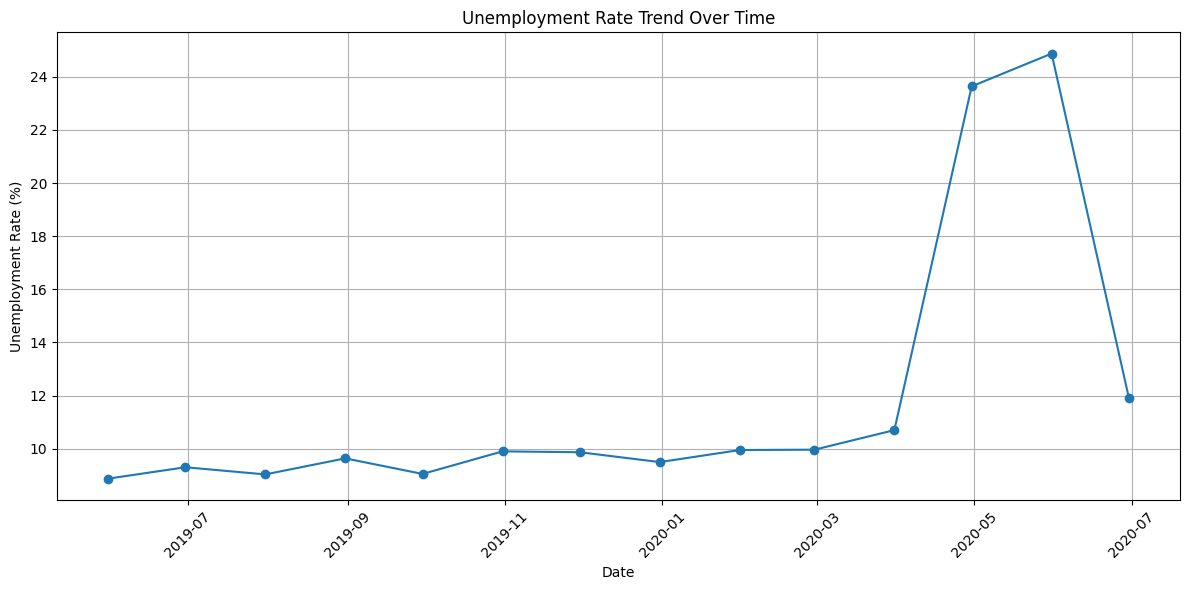

In [25]:
trend = df.groupby('Date')[
    'Estimated Unemployment Rate (%)'
].mean()

plt.figure(figsize=(12, 6))

plt.plot(
    trend.index,
    trend.values,
    marker='o'
)

plt.title('Unemployment Rate Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [26]:
area_analysis = df.groupby('Area')[
    'Estimated Unemployment Rate (%)'
].mean()

print(area_analysis)

Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64


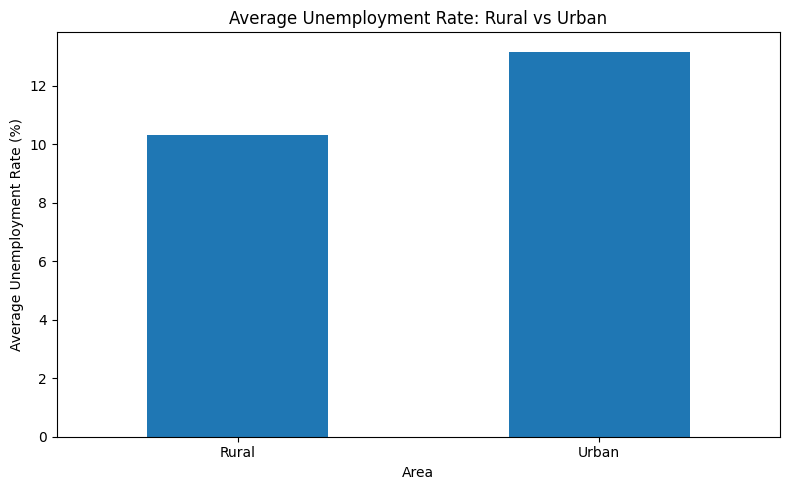

In [27]:
plt.figure(figsize=(8, 5))

area_analysis.plot(kind='bar')

plt.title('Average Unemployment Rate: Rural vs Urban')
plt.xlabel('Area')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [28]:
regional_analysis = df.groupby('Region')[
    'Estimated Unemployment Rate (%)'
].mean().sort_values(ascending=False)

print(regional_analysis)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


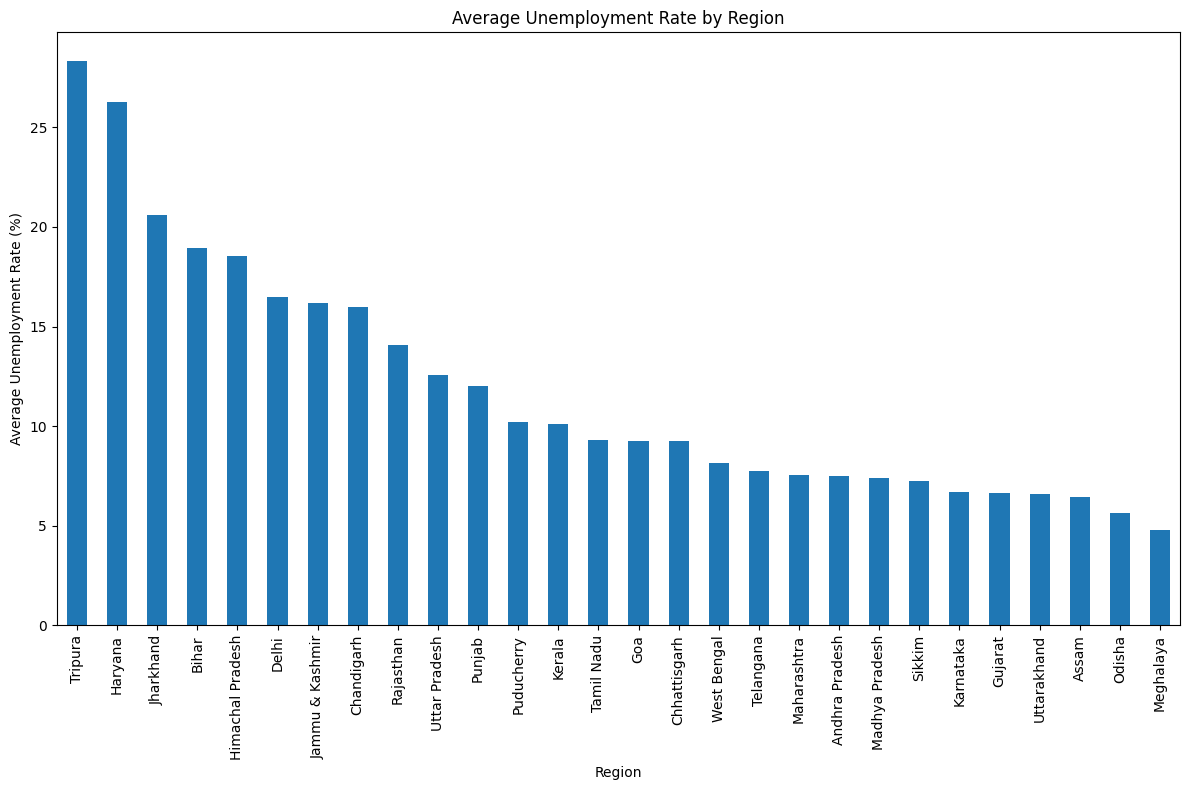

In [29]:
plt.figure(figsize=(12, 8))

regional_analysis.plot(kind='bar')

plt.title('Average Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [30]:
top_10 = regional_analysis.head(10)

print(top_10)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64


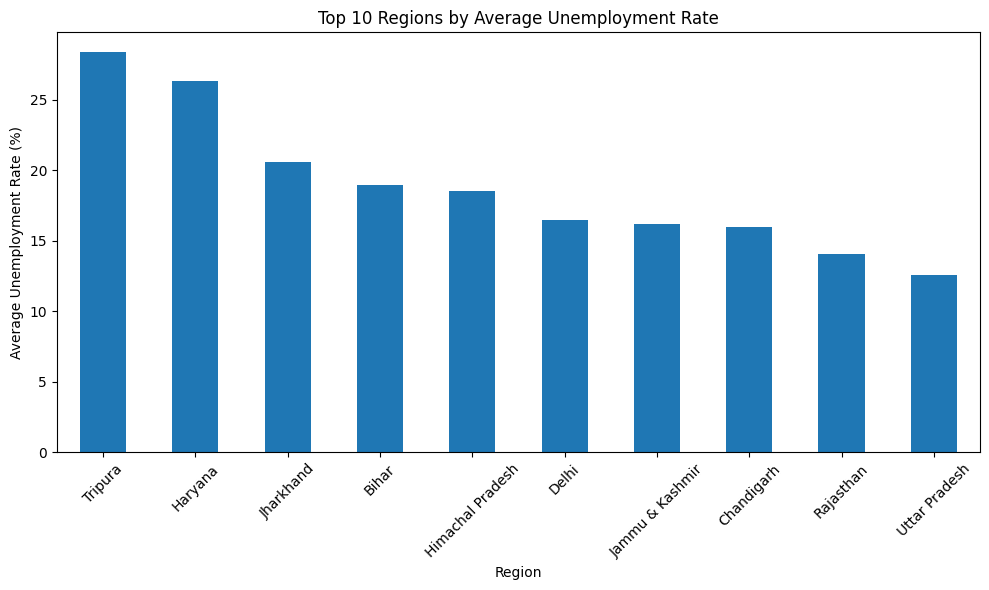

In [31]:
plt.figure(figsize=(10, 6))

top_10.plot(kind='bar')

plt.title('Top 10 Regions by Average Unemployment Rate')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [32]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()

In [33]:
monthly_analysis = df.groupby('Month')[
    'Estimated Unemployment Rate (%)'
].mean()

print(monthly_analysis)

Month
1      9.950755
2      9.964717
3     10.700577
4     23.641569
5     16.646190
6     10.553462
7      9.033889
8      9.637925
9      9.051731
10     9.900909
11     9.868364
12     9.497358
Name: Estimated Unemployment Rate (%), dtype: float64


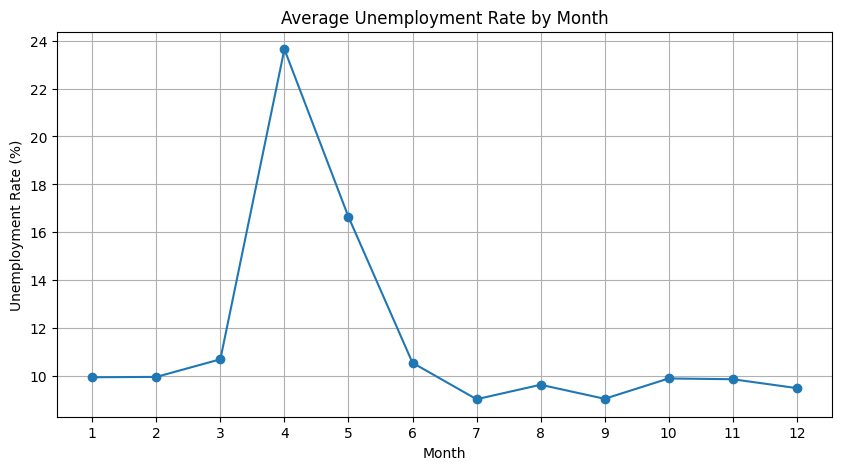

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_analysis.index,
    monthly_analysis.values,
    marker='o'
)

plt.title('Average Unemployment Rate by Month')
plt.xlabel('Month')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

## COVID-19 Impact on Unemployment

The unemployment rate is analyzed around the COVID-19 period to
identify changes in unemployment during 2020 compared with the
pre-COVID period.

In [35]:
df['COVID_Period'] = np.where(
    df['Date'] < pd.Timestamp('2020-03-01'),
    'Before COVID-19',
    'COVID-19 Period'
)

In [36]:
covid_comparison = df.groupby('COVID_Period')[
    'Estimated Unemployment Rate (%)'
].mean()

print(covid_comparison)

COVID_Period
Before COVID-19     9.509534
COVID-19 Period    17.774363
Name: Estimated Unemployment Rate (%), dtype: float64


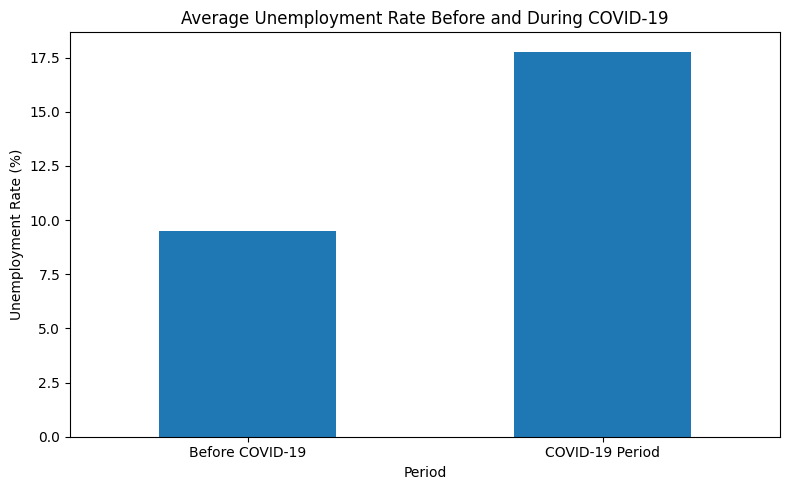

In [37]:
plt.figure(figsize=(8, 5))

covid_comparison.plot(kind='bar')

plt.title(
    'Average Unemployment Rate Before and During COVID-19'
)

plt.xlabel('Period')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [38]:
df_covid.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74


In [39]:
print(df_covid.shape)
print(df_covid.columns.tolist())

(267, 9)
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


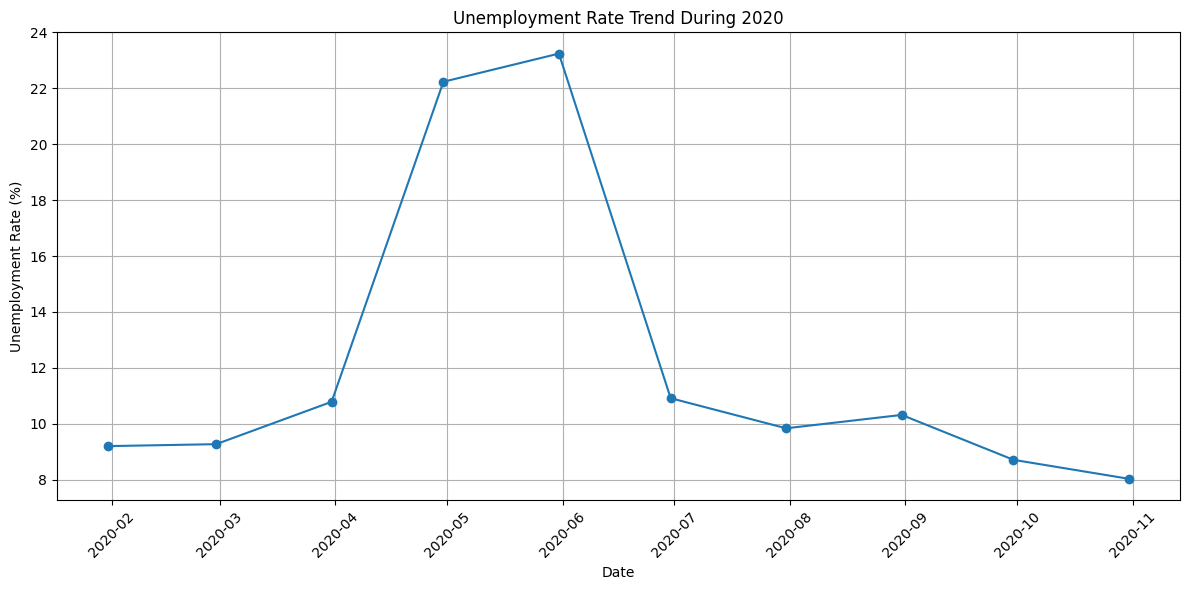

In [40]:
covid_trend = df_covid.groupby('Date')[
    'Estimated Unemployment Rate (%)'
].mean()

plt.figure(figsize=(12, 6))

plt.plot(
    covid_trend.index,
    covid_trend.values,
    marker='o'
)

plt.title('Unemployment Rate Trend During 2020')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [41]:
covid_highest = df_covid.loc[
    df_covid['Estimated Unemployment Rate (%)'].idxmax()
]

print(covid_highest)

Region                                              Puducherry
Date                                       2020-04-30 00:00:00
Frequency                                                    M
Estimated Unemployment Rate (%)                          75.85
Estimated Employed                                      117542
Estimated Labour Participation Rate (%)                   39.3
Region.1                                                 South
longitude                                              11.9416
latitude                                               79.8083
Name: 172, dtype: object


In [42]:
covid_lowest = df_covid.loc[
    df_covid['Estimated Unemployment Rate (%)'].idxmin()
]

print(covid_lowest)

Region                                               Karnataka
Date                                       2020-08-31 00:00:00
Frequency                                                    M
Estimated Unemployment Rate (%)                            0.5
Estimated Employed                                    24094289
Estimated Labour Participation Rate (%)                  43.13
Region.1                                                 South
longitude                                              15.3173
latitude                                               75.7139
Name: 116, dtype: object


In [43]:
covid_region = df_covid.groupby('Region')[
    'Estimated Unemployment Rate (%)'
].mean().sort_values(ascending=False)

print(covid_region)

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Goa                 12.167000
Punjab              11.981000
Uttarakhand         11.156000
West Bengal         10.192000
Sikkim               9.792500
Uttar Pradesh        9.737000
Kerala               9.434000
Andhra Pradesh       8.664000
Maharashtra          7.979000
Chhattisgarh         7.819000
Karnataka            7.668000
Madhya Pradesh       6.854000
Telangana            6.833000
Odisha               6.462000
Gujarat              6.376000
Assam                4.856000
Meghalaya            3.866000
Name: Estimated Unemployment Rate (%), dtype: float64


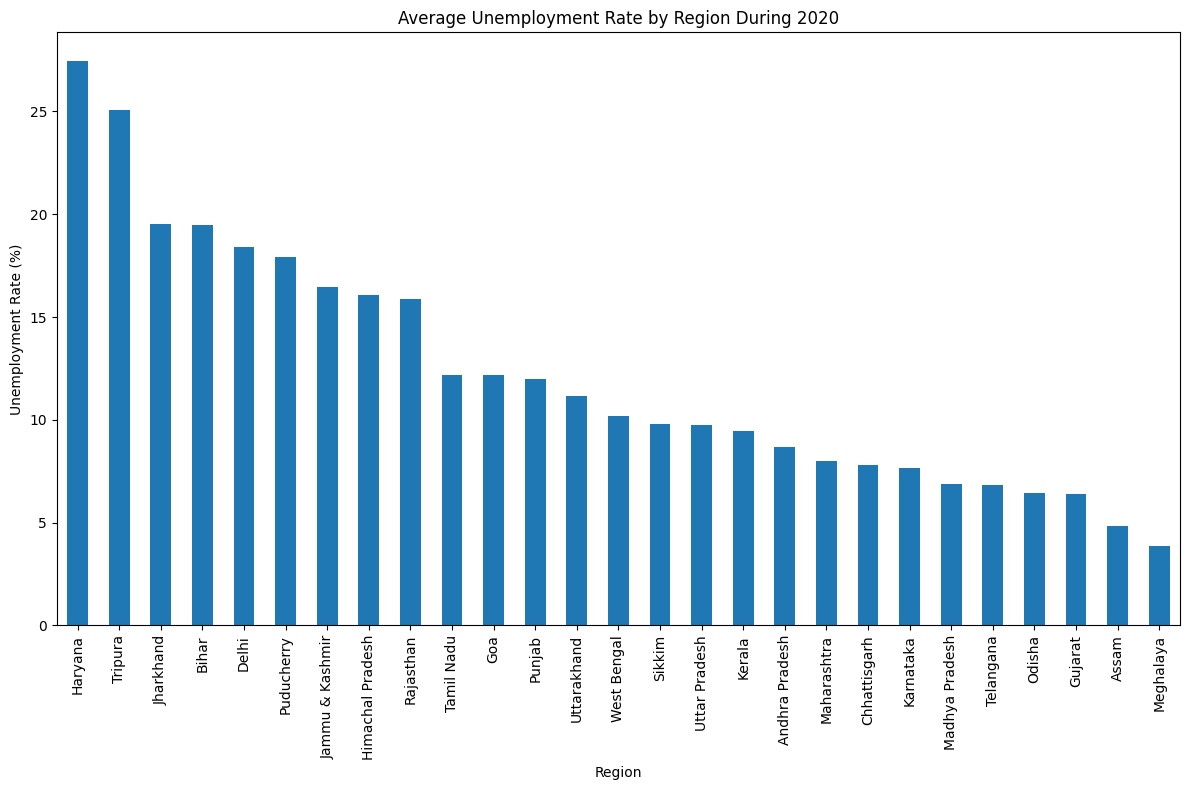

In [44]:
plt.figure(figsize=(12, 8))

covid_region.plot(kind='bar')

plt.title(
    'Average Unemployment Rate by Region During 2020'
)

plt.xlabel('Region')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [45]:
correlation = df[
    [
        'Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)'
    ]
].corr()

print(correlation)

                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                 1.000000   
Estimated Employed                                             -0.222876   
Estimated Labour Participation Rate (%)                         0.002558   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                   -0.222876   
Estimated Employed                                 1.000000   
Estimated Labour Participation Rate (%)            0.011300   

                                         Estimated Labour Participation Rate (%)  
Estimated Unemployment Rate (%)                                         0.002558  
Estimated Employed                                                      0.011300  
Estimated Labour Participation Rate (%)                                 1.000000  


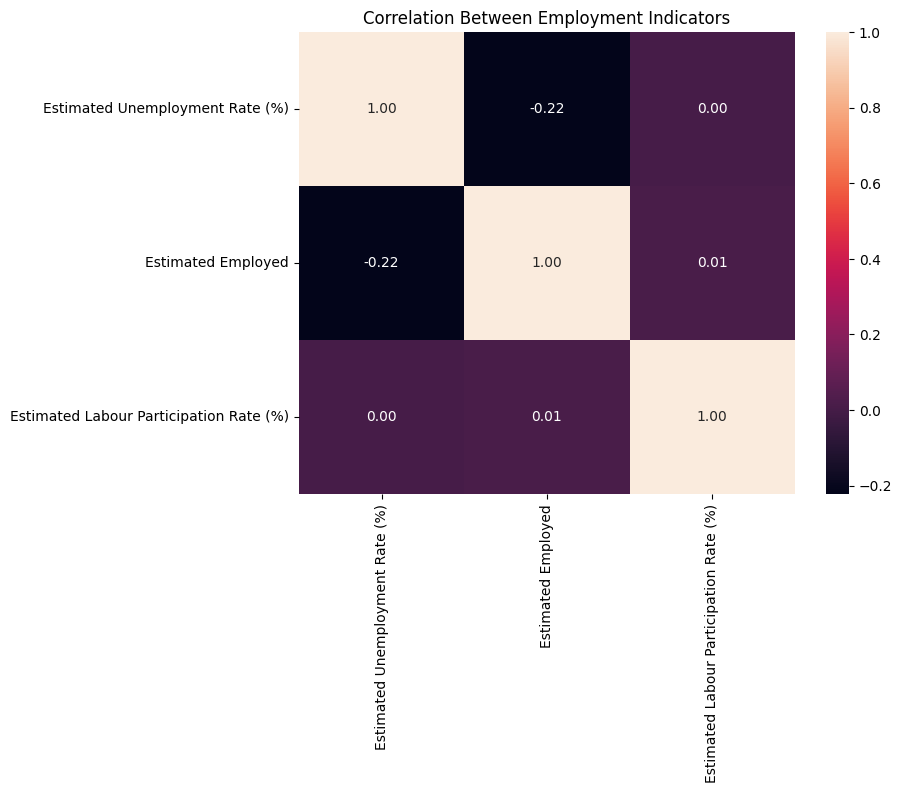

In [46]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Between Employment Indicators')

plt.show()

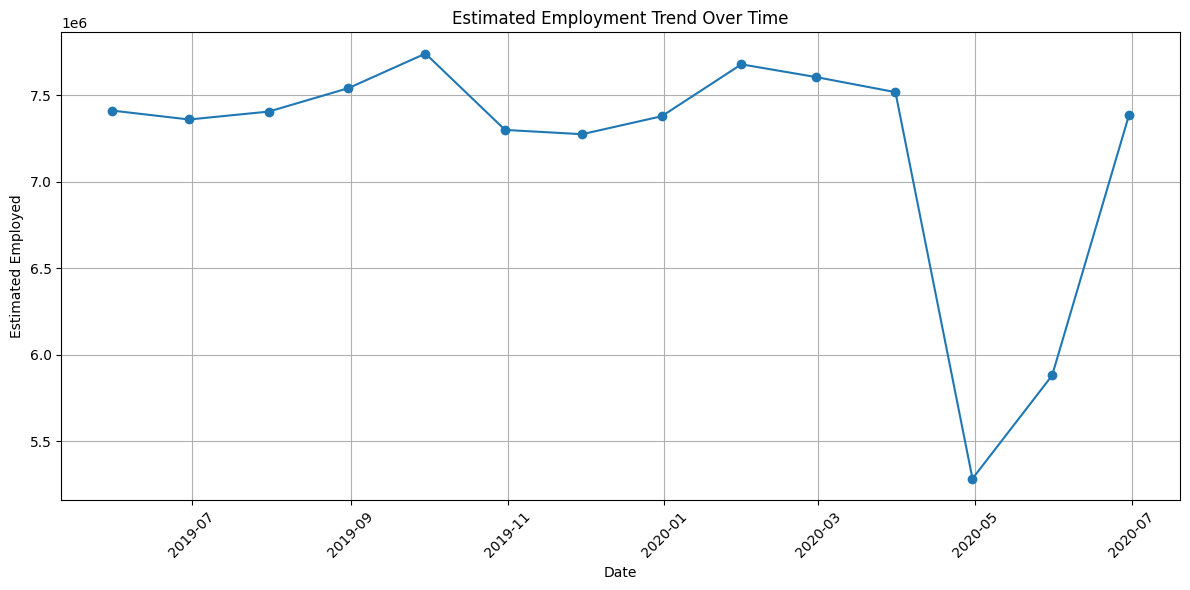

In [47]:
employment_trend = df.groupby('Date')[
    'Estimated Employed'
].mean()

plt.figure(figsize=(12, 6))

plt.plot(
    employment_trend.index,
    employment_trend.values,
    marker='o'
)

plt.title('Estimated Employment Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Estimated Employed')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

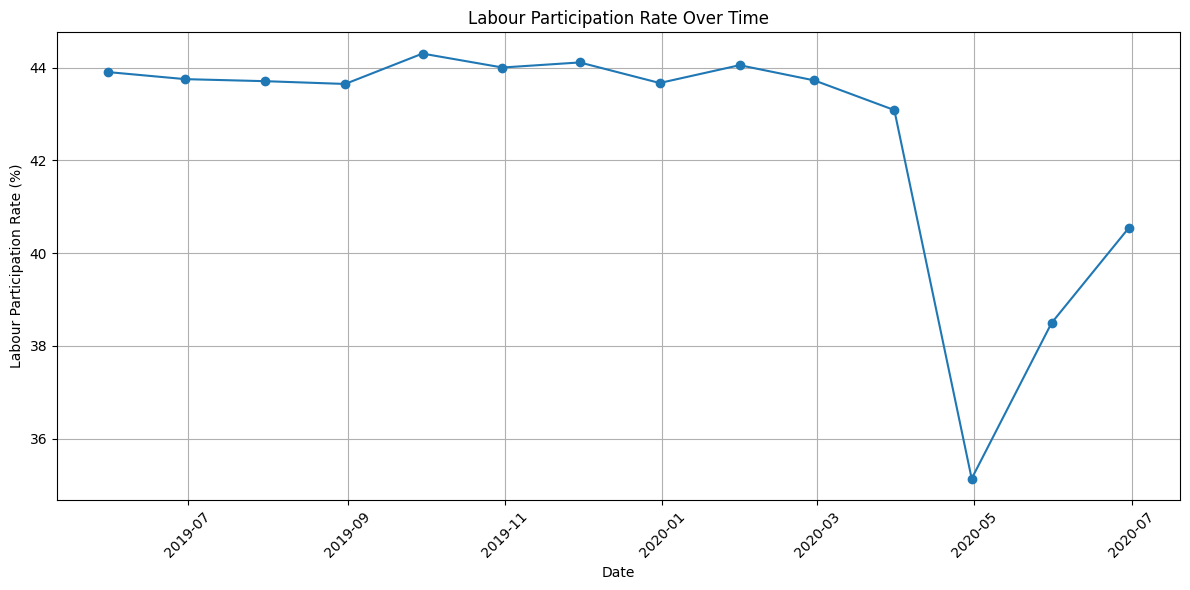

In [48]:
participation_trend = df.groupby('Date')[
    'Estimated Labour Participation Rate (%)'
].mean()

plt.figure(figsize=(12, 6))

plt.plot(
    participation_trend.index,
    participation_trend.values,
    marker='o'
)

plt.title('Labour Participation Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Labour Participation Rate (%)')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

## Key Insights

1. The analysis contains 740 valid records after data cleaning, with
   no remaining missing values or duplicate rows.

2. The overall average unemployment rate during the observed period
   was 11.79%.

3. Urban areas had a higher average unemployment rate (13.17%)
   compared with rural areas (10.32%).

4. There were substantial differences between regions. Tripura had
   the highest average unemployment rate at 28.35%, followed by
   Haryana at 26.28% and Jharkhand at 20.59%. Meghalaya had the
   lowest average at 4.80%.

5. The unemployment rate showed a major monthly spike in April,
   reaching an average of 23.64%, followed by 16.65% in May.
   Other months generally remained around 9% to 11%.

6. The COVID-19 period showed a significant increase in unemployment.
   The average unemployment rate increased from 9.51% before
   COVID-19 to 17.77% during the COVID-19 period, an increase of
   approximately 8.26 percentage points.

7. The highest individual unemployment rate in the main dataset was
   76.74% in Puducherry in April 2020, while the lowest was 0% in
   Assam in June 2020.

8. In the dedicated 2020 dataset, Haryana had the highest regional
   average unemployment rate at 27.48%, followed by Tripura at
   25.06% and Jharkhand at 19.54%.

9. The correlation between unemployment and estimated employment was
   -0.22, indicating a weak negative relationship. The correlation
   between unemployment and labour participation was approximately
   zero (0.003), indicating little linear relationship in this
   dataset.

10. Overall, the analysis shows strong regional and time-based
    differences in unemployment, with a particularly noticeable
    increase around the COVID-19 period. These findings can help
    identify regions and periods that may require greater attention
    in employment and economic policies.

# Conclusion

This project analyzed unemployment data using Python, Pandas,
NumPy, Matplotlib, and Seaborn.

The analysis included data cleaning, exploratory data analysis,
regional analysis, rural and urban comparison, monthly trend
analysis, employment analysis, labour participation analysis, and
COVID-19 impact analysis.

The results demonstrate changes in unemployment over time and
differences between regions and areas. The COVID-19 period was
examined to understand changes in unemployment during the pandemic.

Overall, the project demonstrates how data analysis and
visualization can be used to identify important labour-market
patterns and provide insights that may support economic and social
decision-making.